In [1]:
!pip install soundfile simpleaudio librosa scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for simpleaudio
  Running setup.py clean for simpleaudio
Failed to build simpleaudio
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (simpleaudio)


In [23]:
from IPython.display import Audio


playing the audio

In [24]:
Audio(filename="/content/sample.wav.wav")


In [25]:
Audio(data=sliced_signal, rate=sr)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf


reading the sound file

In [6]:
audio_path = "/content/sample.wav.wav"

signal, sr = librosa.load(audio_path, sr=None)

duration = len(signal) / sr

print("Sample Rate:", sr)
print("Number of Samples:", len(signal))
print("Total Duration (sec):", duration)




Sample Rate: 22050
Number of Samples: 185146
Total Duration (sec): 8.396643990929705


Plot the waveform of speech signal (time-domain signal)

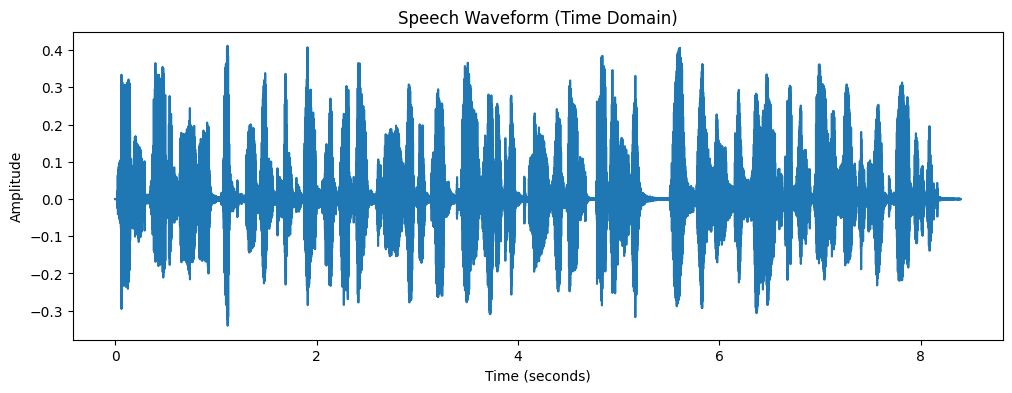

In [7]:
time = np.linspace(0, duration, num=len(signal))

plt.figure(figsize=(12,4))
plt.plot(time, signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Speech Waveform (Time Domain)")
plt.show()


Active Speech Duration (Energy-based)


In [ ]:
Signal used here

signal = entire speech file (full LJ Speech audio)

Not the 2-second sliced signal

In [27]:
energy = signal**2
threshold = 0.01 * np.max(energy)

active_samples = energy > threshold
active_duration = np.sum(active_samples) / sr

print("Active Speech Duration (sec):", active_duration)


Active Speech Duration (sec): 2.7208163265306125


Slicing (First 2 sec) & plot

In [9]:
slice_duration = 2  # seconds
num_samples = int(slice_duration * sr)

sliced_signal = signal[:num_samples]

print("Sliced signal duration (sec):", len(sliced_signal)/sr)


Sliced signal duration (sec): 2.0


plot the sliced signal

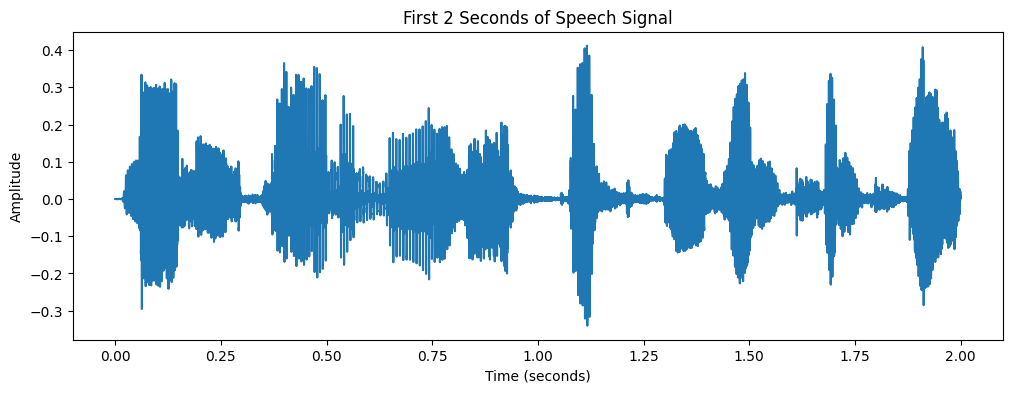

In [10]:
time_slice = np.linspace(0, slice_duration, num=len(sliced_signal))

plt.figure(figsize=(12,4))
plt.plot(time_slice, sliced_signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("First 2 Seconds of Speech Signal")
plt.show()


Normalize the Sliced Signal & plot

In [11]:
normalized_signal = sliced_signal / np.max(np.abs(sliced_signal))


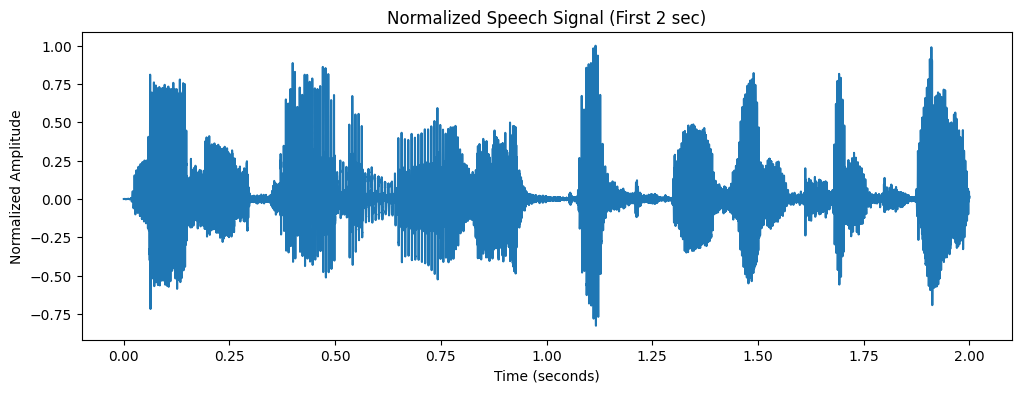

In [12]:
plt.figure(figsize=(12,4))
plt.plot(time_slice, normalized_signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title("Normalized Speech Signal (First 2 sec)")
plt.show()


Amplification & De-amplification

In [13]:
amplified_signal = 2 * sliced_signal
deamplified_signal = 0.5 * sliced_signal


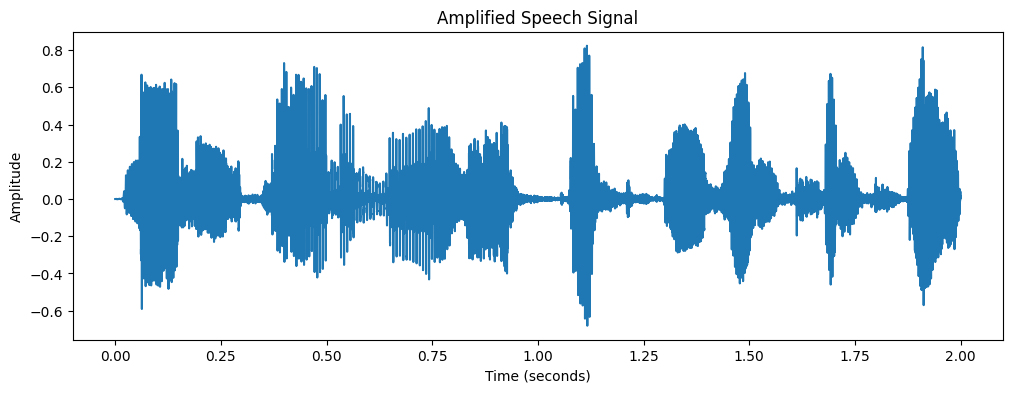

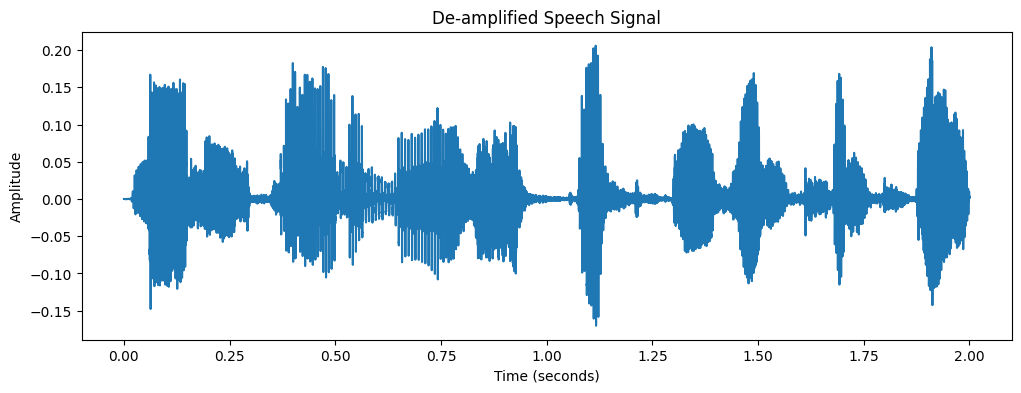

In [14]:
plt.figure(figsize=(12,4))
plt.plot(time_slice, amplified_signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Amplified Speech Signal")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(time_slice, deamplified_signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("De-amplified Speech Signal")
plt.show()


Up-sampling

In [15]:
upsampled_signal = np.repeat(sliced_signal, 2)
upsampled_sr = sr * 2

time_up = np.linspace(0, slice_duration, num=len(upsampled_signal))


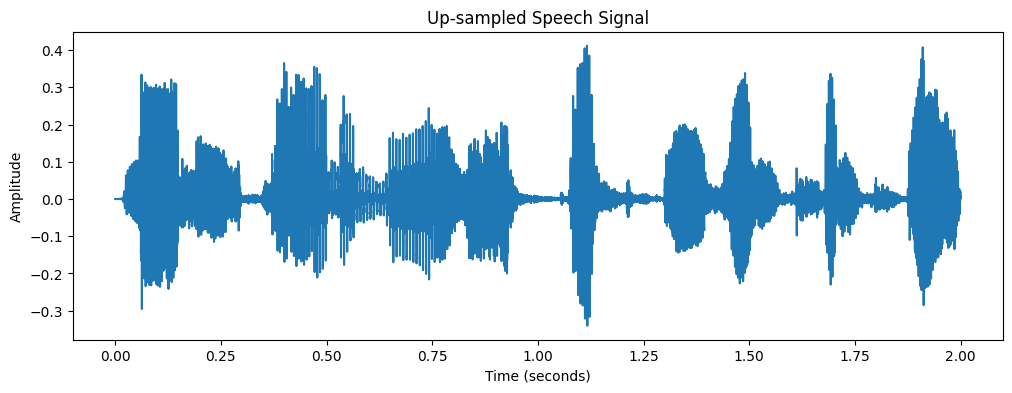

In [16]:
plt.figure(figsize=(12,4))
plt.plot(time_up, upsampled_signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Up-sampled Speech Signal")
plt.show()


Down-sampling

In [17]:
downsampled_signal = sliced_signal[::2]
downsampled_sr = sr // 2

time_down = np.linspace(0, slice_duration, num=len(downsampled_signal))


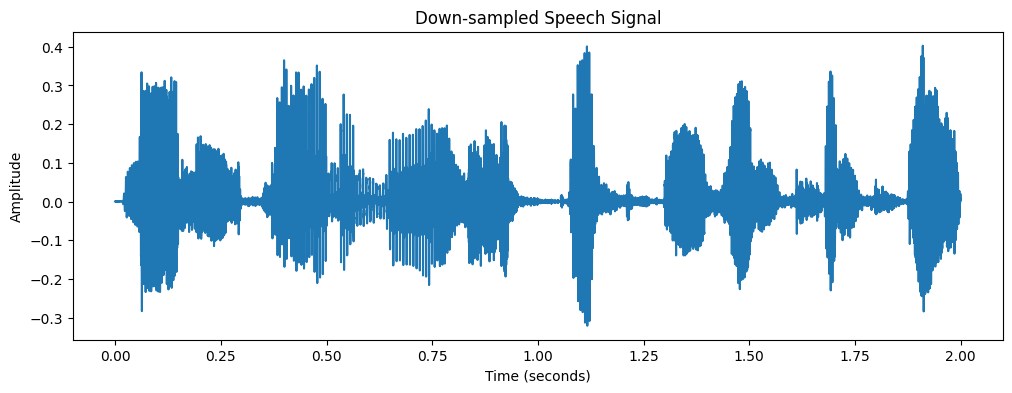

In [18]:
plt.figure(figsize=(12,4))
plt.plot(time_down, downsampled_signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Down-sampled Speech Signal")
plt.show()


Re-plot with Clear View

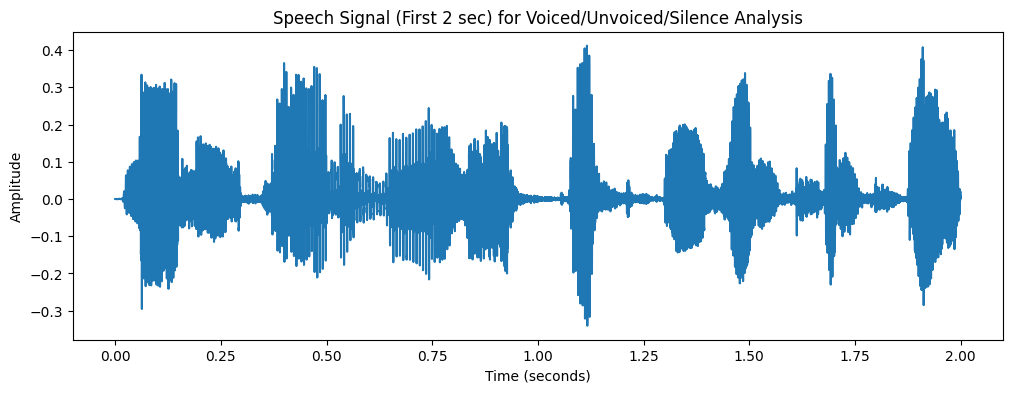

In [21]:
plt.figure(figsize=(12,4))
plt.plot(time_slice, sliced_signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Speech Signal (First 2 sec) for Voiced/Unvoiced/Silence Analysis")
plt.show()
